In [22]:
# step 1 = import lib

import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [23]:
# step 2 = create data customers 

customers = np.array(
    [   # parchase frequency, annual income
        [20, 50000], # Rohit
        [25, 60000], # Priya
        [30, 55000], # Ankit
        [35, 80000], # Neha
        [40, 75000], # Rahul
        [45, 90000], # Suman
        [50, 85000], # Pooja
        [55, 95000], # Arjun
        [60, 100000], # Kavita
        [65, 110000], # Rakesh
        [40, 70000], # Anjali
        [45, 65000], # Vikram
        [50, 72000], # Meera
        [55, 68000], # Suresh
        [60, 75000], # Priyanka
        [65, 80000], # Amit
        [70, 85000], # Sunita
        [75, 90000], # Ramesh
        [80, 95000], # Neelam
        [85, 100000], # Sandeep
        [67, 105000], # Anil
        [72, 110000], # Rekha
        [77, 115000], # Manoj
        [82, 120000], # Shweta
    ]
)

In [24]:
# kmean with 2 cluster(group)
# 1st group = low income and low age
# 2nd group = high income and high age

kmeans = KMeans(n_clusters=4, # number of cluster
                random_state=0)

kmeans.fit(customers) # fit the model to the data
    

,n_clusters,4
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,0
,copy_x,True
,algorithm,'lloyd'


In [25]:
# group  labels = kmeans.labels_ # get the cluster labels for each data point
labels = kmeans.labels_
print(labels)

# rename the labels to 0 and 1
# labels = np.where(labels == 0, 'Low Income & Low Age', 'High Income & High Age')
# print(labels)

# centroid = kmeans.cluster_centers_ # get the cluster centroids
centroid = kmeans.cluster_centers_
print(centroid)

[3 3 3 2 0 2 2 2 1 1 0 0 0 0 0 2 2 2 2 1 1 1 1 1]
[[4.83333333e+01 7.08333333e+04]
 [7.25714286e+01 1.08571429e+05]
 [5.93750000e+01 8.75000000e+04]
 [2.50000000e+01 5.50000000e+04]]


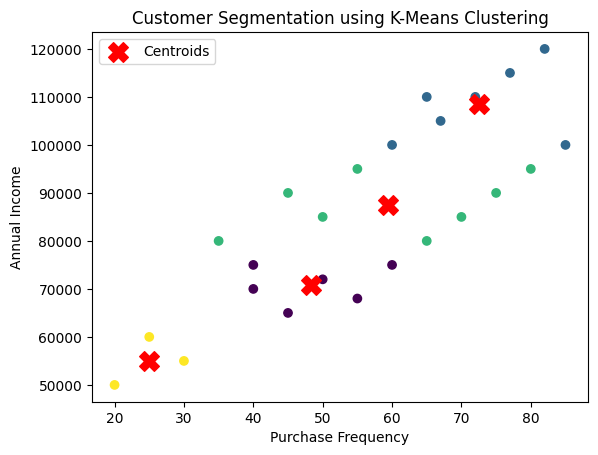

In [26]:
# draw the clusters
plt.scatter(customers[:, 0], # purchase frequency
            customers[:, 1], # annual income
            c=labels, # color by cluster labels
            cmap='viridis' # color map
            )

plt.scatter(centroid[:, 0], # purchase frequency of centroids
            centroid[:, 1], # annual income of centroids
            c='red', # color of centroids
            marker='X', # marker for centroids
            s=200, # size of centroids
            label='Centroids' # label for legend
            )

plt.xlabel('Purchase Frequency')
plt.ylabel('Annual Income')
plt.title('Customer Segmentation using K-Means Clustering')
plt.legend()
plt.show()


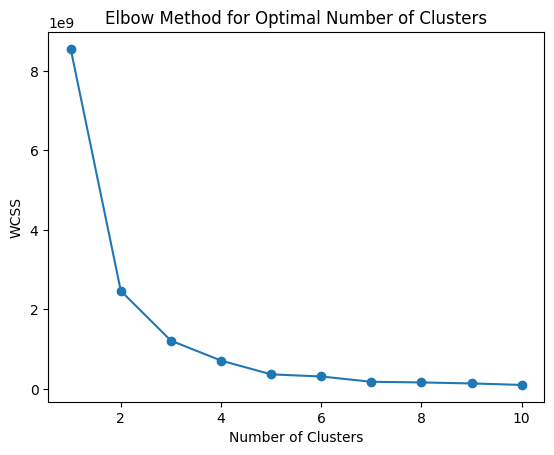

In [27]:
# Elbow trick to find the optimal number of cluster
wcss = [] # within cluster sum of squares
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=0)
    kmeans.fit(customers)
    wcss.append(kmeans.inertia_) # inertia_ is the wcss for the current number of clusters
    
    
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method for Optimal Number of Clusters')
plt.show()    